This is my code for the Analysis and Modeling

LOAD IN LIBRARIES FIRST

In [21]:
import pandas as pd #data manipulation
import numpy as np
import matplotlib.pyplot as plt #visualization
import seaborn as sn #visualization
import requests #api call
from statsmodels.tsa.seasonal import seasonal_decompose #time series decompostion
import plotly.express as px #plot interactivity
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import chi2_contingency #chi-square test
from sklearn.model_selection import train_test_split #modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#Loading in Incidents Data Using an API Call

In [22]:
#creating a function that loads in the data using an API call
def api_to_dataframe(url):
   #getting the total number of rows in the API
    count_url = f"{url}?$select=count(*)"
    count_response = requests.get(count_url)
    total_count = int(count_response.json()[0]['count']) #this variable indicates the number of records/rows
    print(f"Total rows found: {total_count}")
    #checking if the URL already has query parameters(?) and also setting the limit to the maximum number of records
    if '?' in url:
        url_with_limit = f"{url}&$limit={total_count}"
    else:
        url_with_limit = f"{url}?$limit={total_count}"
    #making the web request to fetch the data and storing the result in a pandas dataframe
    response = requests.get(url_with_limit)
    data = response.json()
    return pd.DataFrame(data)

#Calling in the function and plugging in the api url from data montgomery
incidents_df = api_to_dataframe("https://data.montgomerycountymd.gov/resource/bhju-22kf.json")

# dropping  columns that are not part of the data and checking the first few lines
columns_to_drop = [col for col in incidents_df.columns if col.startswith(':')]
incidents_df = incidents_df.drop(columns=columns_to_drop)

Total rows found: 121640


##Cleaning Incidents Data

In [23]:
#removing capitalization for different verisons of the same categorical values
cols_to_clean = ['light', 'weather', 'surface_condition', 'collision_type', 'road_grade', 'road_condition']
for col in cols_to_clean:
  incidents_df[col] = incidents_df[col].str.lower()

#generalizing categorical values
incidents_df["weather"] = incidents_df["weather"].replace({'raining': 'rain', 'blowing snow': 'snow','foggy':'fog, smog, smoke', 'sleet':'sleet or hail', 'severe crosswinds':'severe winds', 'freezing rain or freezing drizzle':'wintry mix'})
incidents_df["weather"] = incidents_df["weather"].replace({ 'blowing sand, soil, dirt':'adverse weather', 'fog, smog, smoke': 'adverse weather', 'severe winds': 'adverse weather', 'rain':'precipitation', 'wintry mix': 'precipitation', 'snow':'precipitation', 'sleet or hail': 'precipitation', 'other':'unknown'})
incidents_df['light'] = incidents_df['light'].replace({'dark - lighted': 'dark', 'dark - not lighted': 'dark', 'dark - unknown lighting': 'dark', 'dark -- unknown lighting': 'dark', 'dark lights on': 'dark', 'dark no lights': 'dark' })

#coverting date column to datetime object for time-series functionality
if incidents_df.index.name == 'crash_date_time': #check if 'crash_date_time' is already the index and reset if necessary
    incidents_df.reset_index(inplace=True)
incidents_df['crash_date_time'] = pd.to_datetime(incidents_df['crash_date_time'], format='ISO8601')
incidents_df.set_index('crash_date_time', inplace=True)

#making a new copy of the cleaned dataset and storing it under a new name
cleaned_incidents_df = incidents_df.copy()

In [24]:
#exporting the cleaned_incidents_df to a CSV file
cleaned_incidents_df.to_csv('cleaned_incidents_data.csv', index=False)

#Loading in Drivers Data Using an API Call

In [25]:
#loading in the second dataset and checking the first few lines
drivers_df = api_to_dataframe("https://data.montgomerycountymd.gov/resource/mmzv-x632.json") #using the previously created function
columns_to_drop = [col for col in drivers_df.columns if col.startswith(':')]  #
drivers_df = drivers_df.drop(columns=columns_to_drop)

Total rows found: 214273


##Cleaning Drivers Data

In [26]:
#removing capitalization for different verisons of the same categorical values
cols_to_clean = ['light', 'weather', 'surface_condition', 'collision_type', 'injury_severity', 'vehicle_damage_extent', 'vehicle_movement', 'vehicle_first_impact_location']
for col in cols_to_clean:
  drivers_df[col] = drivers_df[col].str.lower()

#generalizing categorical values
drivers_df["weather"] = drivers_df["weather"].replace({'raining': 'rain', 'blowing snow': 'snow','foggy':'fog, smog, smoke', 'sleet':'sleet or hail', 'severe crosswinds':'severe winds', 'freezing rain or freezing drizzle':'wintry mix'})
drivers_df['light'] = drivers_df['light'].replace({'dark - lighted': 'dark', 'dark - not lighted': 'dark', 'dark - unknown lighting': 'dark', 'dark -- unknown lighting': 'dark', 'dark lights on': 'dark', 'dark no lights': 'dark' })

#coverting date column to datetime object
if drivers_df.index.name == 'crash_date_time': #check if 'crash_date_time' is already the index and reset if necessary
    drivers_df.reset_index(inplace=True)
drivers_df['crash_date_time'] = pd.to_datetime(drivers_df['crash_date_time'], format='ISO8601')
drivers_df.set_index('crash_date_time', inplace=True)

#making a new copy of the cleaned dataset and storing it under a new name
cleaned_drivers_df = drivers_df.copy()

In [27]:
#exporting the cleaned_drivers_df to a CSV file
cleaned_drivers_df.to_csv('cleaned_drivers_data.csv', index=False)

#**Analysis and Modeling**

###**Which roads have seen the most collision incidents?** <br>
I will make a simple countplot to answer this question. I will add the factor of collision type.

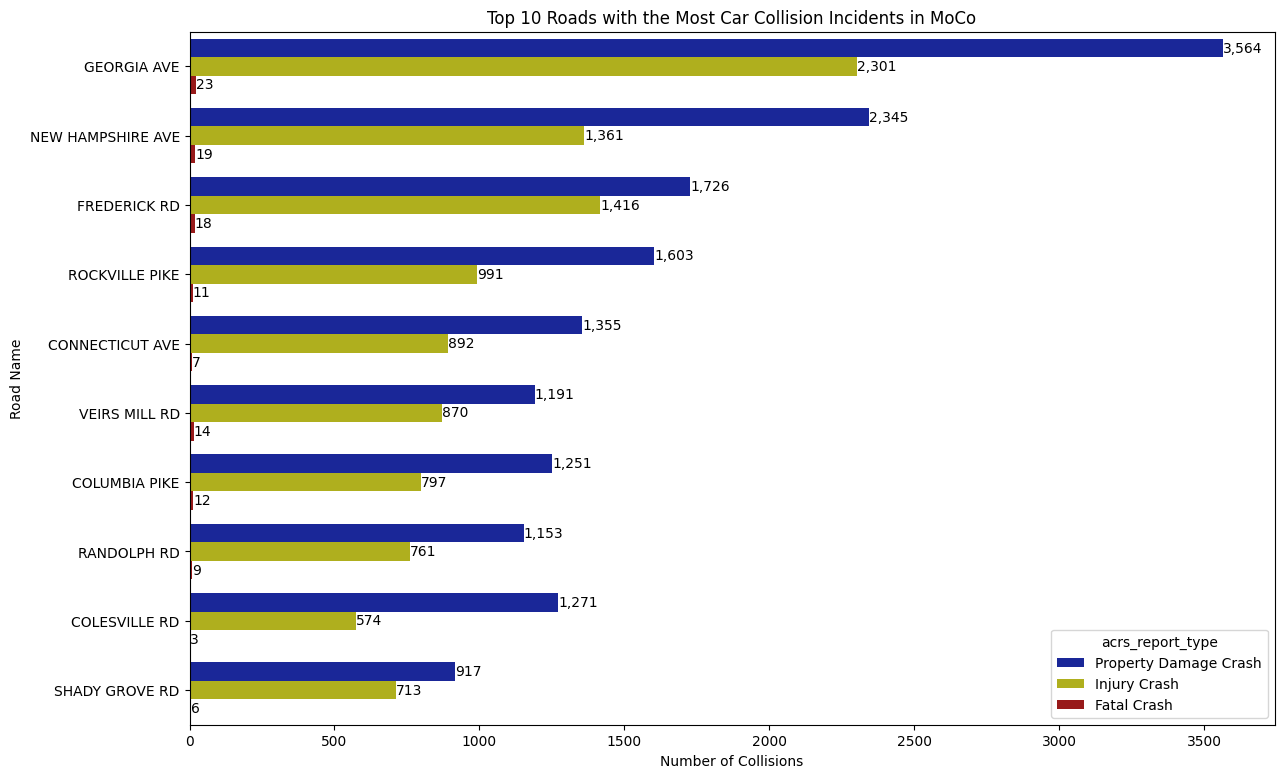

In [28]:
top10_roads = incidents_df[incidents_df['road_name'].isin(incidents_df['road_name'].value_counts().head(10).index)]
plt.figure(figsize=(14,9))
p2 = sn.countplot(y = "road_name", data = top10_roads, hue='acrs_report_type',palette=['#0516ad', '#c7c706', '#ad0505'], order = top10_roads["road_name"].value_counts().index)
plt.title("Top 10 Roads with the Most Car Collision Incidents in MoCo")
plt.xlabel("Number of Collisions")
plt.ylabel('Road Name')
for container in p2.containers:       #to display the actual values with commas next to the bar graphs
    p2.bar_label(container, fmt='{:,.0f}')
plt.show()

###**How has the number of car collision incidents changed over time since 2015?** <br>
To answer this question I will make a time series line graph. There is a very noticable sharp decline of car collsions in 2020 as a result of Covid-19. Additionally, there is a consistent fluctuation pattern happening throughout the whole series. This opens up a new path for exploration.

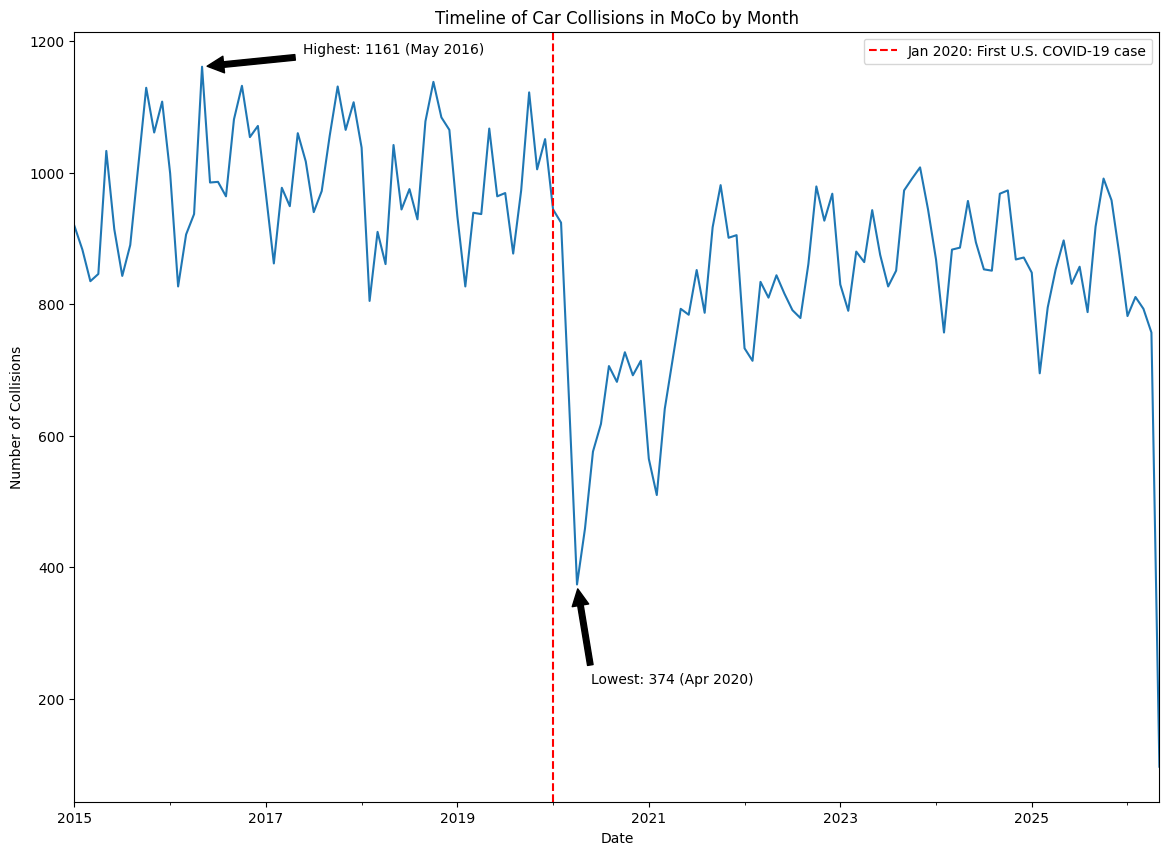

In [29]:
plt.figure(figsize=(14,10))
monthly_counts = incidents_df.resample('ME').size()  #resampling to a monthly frequency
monthly_counts.plot(kind='line', title='Timeline of Car Collisions in MoCo by Month')
plt.ylabel('Number of Collisions')
plt.xlabel('Date')

#adding a dashed line for January 2020
plt.axvline(pd.to_datetime('2020-01-01'), color='red', linestyle='--', label='Jan 2020: First U.S. COVID-19 case')

#finding the highest peak
highest_peak_date = monthly_counts.idxmax()
highest_peak_value = monthly_counts.max()
plt.annotate(f'Highest: {highest_peak_value} ({highest_peak_date.strftime('%b %Y')})',
 xy=(highest_peak_date, highest_peak_value),
 xytext=(highest_peak_date + pd.DateOffset(years=2), highest_peak_value + 20),
 arrowprops=dict(facecolor='black', shrink=0.05),
 ha='center')

#finding the absolute lowest trough, excluding the current incomplete month
second_lowest_series = monthly_counts.nsmallest(2)
lowest_trough_value = second_lowest_series.iloc[1]
lowest_trough_date = second_lowest_series.index[1]

plt.annotate(f'Lowest: {lowest_trough_value} ({lowest_trough_date.strftime('%b %Y')})',
  xy=(lowest_trough_date, lowest_trough_value),
  xytext=(lowest_trough_date + pd.DateOffset(years=1), lowest_trough_value  -150),
  arrowprops=dict(facecolor='black', shrink=0.05),
  ha='center')

plt.legend()
plt.show()

###Interactive Timeline of Car Collisions <br>
Here is an interactive version of the timeline chart, allowing us to zoom and identify each month. I am keeping the first timeline chart without interactivity because it is simpler and looks better.

In [30]:
monthly_counts = incidents_df.resample('ME').size() #resampling by month

#converting monthly_counts to Dataframe for Plotly
monthly_counts_df = monthly_counts.reset_index()
monthly_counts_df.columns = ['Date', 'Number of Collisions']
fig_timeline = px.line(
    monthly_counts_df,
    x='Date',
    y='Number of Collisions',
    title='Interactive Timeline of Car Collisions in MoCo by Month')

#adding dashed line for January 2020
fig_timeline.add_vline(
x=pd.to_datetime('2020-01-31').timestamp() * 1000,
line_dash="dash",
line_color="red",
annotation_text="Jan 2020: First U.S. COVID-19 case",
annotation_position="top right")

fig_timeline.update_layout(
xaxis_title="Date",
yaxis_title="Number of Collisions",
width=1000,
height=700)
fig_timeline.show()

###**What does the general trend, recurrent fluctuations, and residual components of the time series look like?** <br>
To understand the underlying patterns in the car collision incidents over time, I will decompose the time series into its trend, seasonal, and residual components. This will help us identify the long-term movement, recurring patterns, and any irregular fluctuations.

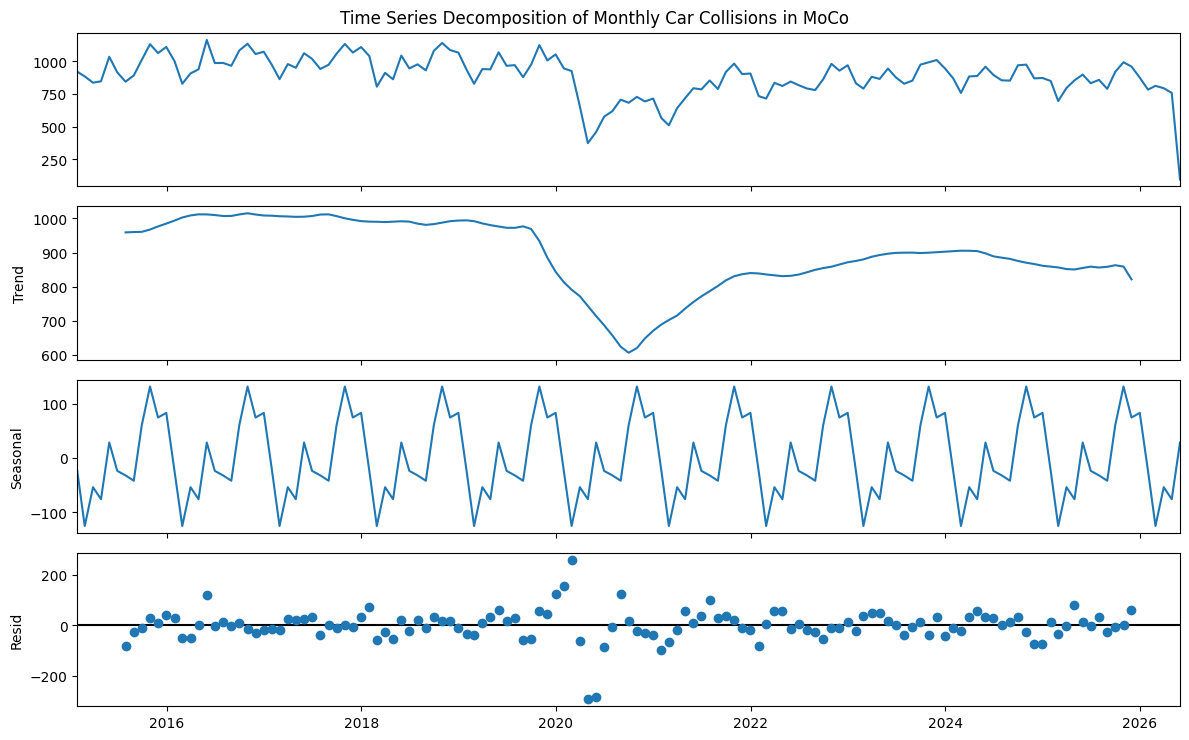

In [31]:
#performing additive decomposition on monthly_counts
decomposition = seasonal_decompose(monthly_counts, model='additive')

#plotting the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Monthly Car Collisions in MoCo', y = 0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) #adjusting layout to prevent overlapping
plt.show()

###Interactive Time Series Decomposition <br>
Here is an interactive version of the time series decomposition, allowing us to hover over months and gather insights. I am keeping the above strucural decompostion because it is simpler and looks better.

In [32]:
#performing additive decomposition on monthly_counts
decomposition = seasonal_decompose(monthly_counts, model='additive')

#extracting components
observed = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

#creating subplots
fig_decomposed = make_subplots(
rows=4, cols=1,
shared_xaxes=True,
subplot_titles=('Observed', 'Trend', 'Seasonal', 'Residual'),
vertical_spacing=0.05) # Adjust this value to reduce spacing

#adding traces for each component
fig_decomposed.add_trace(go.Scatter(x=observed.index, y=observed.values, mode='lines', name='Observed'), row=1, col=1)
fig_decomposed.add_trace(go.Scatter(x=trend.index, y=trend.values, mode='lines', name='Trend'), row=2, col=1)
fig_decomposed.add_trace(go.Scatter(x=seasonal.index, y=seasonal.values, mode='lines', name='Seasonal'), row=3, col=1)
fig_decomposed.add_trace(go.Scatter(x=residual.index, y=residual.values, mode='lines', name='Residual'), row=4, col=1)

#updating layout
fig_decomposed.update_layout(
title_text='Interactive Time Series Decomposition of Monthly Car Collisions in MoCo',
height=700,
width=1000,
showlegend=False)
fig_decomposed.show()

###**Which year and month has the most total collision incidents?** <br>
To answer this, I will create two countplots: one that shows the yearly count of collisions also grouped by report type and another that shows the monthly count.

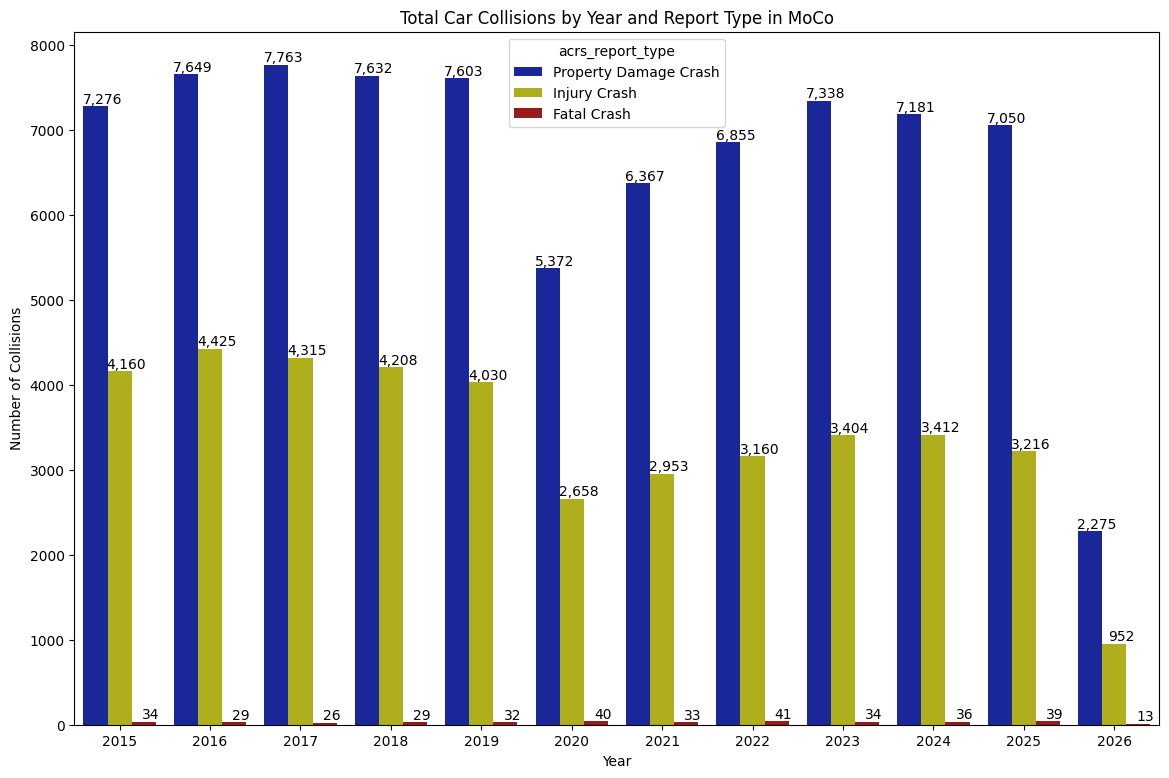

In [33]:
incidents_df['year'] = incidents_df.index.year

plt.figure(figsize=(14, 9))
p_year = sn.countplot(
    x='year',
    data=incidents_df,
    hue='acrs_report_type',
    palette=['#0516ad', '#c7c706', '#ad0505'],
    order=sorted(incidents_df['year'].unique(), reverse=False) # Sort years descending
)
plt.title('Total Car Collisions by Year and Report Type in MoCo')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
for container in p_year.containers:
    labels = p_year.bar_label(container, fmt='{:,.0f}')
    for label in labels:
        # Get current x position and add a small offset in data coordinates
        x, y = label.get_position()
        label.set_x(x + 5) # Shift the label's x-coordinate to the right

plt.show()

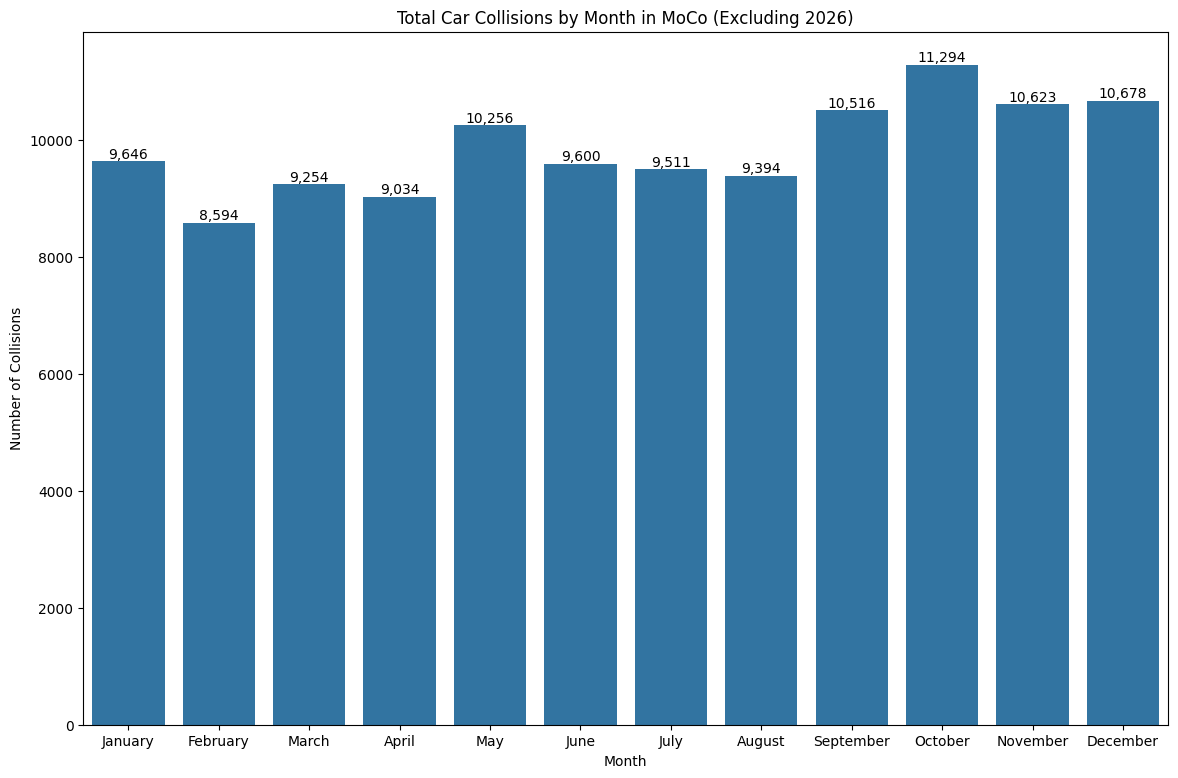

In [34]:
incidents_df['month'] = incidents_df.index.month
incidents_df['month_name'] = incidents_df.index.strftime('%B')

#ordering months chronologically for the plot
month_order = [ 'January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
incidents_df['month_name'] = pd.Categorical(incidents_df['month_name'], categories=month_order, ordered=True)

#filtering out data from the year 2026 because it can cause skewness
incidents_df_filtered = incidents_df[incidents_df.index.year < 2026]

plt.figure(figsize=(14, 9))
p_month = sn.countplot(
    x='month_name',
    data=incidents_df_filtered,
    order=month_order)
plt.title('Total Car Collisions by Month in MoCo (Excluding 2026)')
plt.ylabel('Number of Collisions')
plt.xlabel('Month')
for container in p_month.containers:
    p_month.bar_label(container, fmt='{:,.0f}')
plt.show()

#**Chi-Square Test Statistical Analysis**

In [35]:
# defining values that are going to be filtered out for the Chi-square test because they do not provide anything meaningful to the test
filter_values = ['n/a', 'unknown']
#removing the defined values
chi2_filtered_incidents = cleaned_incidents_df[~cleaned_incidents_df['weather'].isin(filter_values) & ~cleaned_incidents_df['acrs_report_type'].isin(filter_values)].copy()

#creating a contingency table
contingency_table_weather_acrs = pd.crosstab(chi2_filtered_incidents['weather'],chi2_filtered_incidents['acrs_report_type'])
display(contingency_table_weather_acrs)
#performing the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_weather_acrs)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3e}")
print(f"Degrees of freedom: {dof}")

#interpreting the results
alpha = 0.05
if p_value < alpha:
    print("Since the p-value is less than the significance level (0.05), we reject the null hypothesis.\n This means there is a statistically significant relationship betwene the two variables.")
else:
    print("Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis. \n This means there is no statistically significant association between the two variables.")
    print("There is no statistically significant association between the two variables.")

acrs_report_type,Fatal Crash,Injury Crash,Property Damage Crash
weather,,,
adverse weather,4,199,410
clear,298,28327,55823
cloudy,34,4240,7446
precipitation,33,5482,10291



Chi-square statistic: 46.48
P-value: 2.373e-08
Degrees of freedom: 6
Since the p-value is less than the significance level (0.05), we reject the null hypothesis.
 This means there is a statistically significant relationship betwene the two variables.


#**Random Forrest Classification Predictive Modeling**

I will build a classification model that predicts the outcome or 'ACRS Report Type' of car crashes based on the following features: weather, light, surface condition, day of the week, and hour.

In [36]:
#making a copy to avoid modifying the original data
clf_df = cleaned_incidents_df.copy()

#extracting the day of the week (0 for Monday, 6 for Sunday) and hour of the day
clf_df['day_of_week'] = clf_df.index.dayofweek
clf_df['hour'] = clf_df.index.hour

#removing unknown values becaues they are not meaningful
clf_df = clf_df[clf_df['acrs_report_type'] != 'unknown']

#identifying list of columns that will be usedas input features for the model
features_list = ['weather', 'light', 'surface_condition', 'collision_type', 'day_of_week', 'hour']
target = 'acrs_report_type'

#dropping na values
clf_subset = clf_df[features_list + [target]].dropna()

# one-Hot Encoding for categorical variables
X = pd.get_dummies(clf_subset[features_list], drop_first=True)
y = clf_subset[target]

# splitting the data into 80% train and 20% test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train_c)}")
print(f"Testing set size: {len(X_test_c)}")

Training set size: 84837
Testing set size: 21210


Accuracy Score: 0.6104667609618105

Classification Report:
                        precision    recall  f1-score   support

          Fatal Crash       0.00      0.00      0.00        76
         Injury Crash       0.44      0.26      0.33      7669
Property Damage Crash       0.66      0.81      0.73     13465

             accuracy                           0.61     21210
            macro avg       0.37      0.36      0.35     21210
         weighted avg       0.58      0.61      0.58     21210



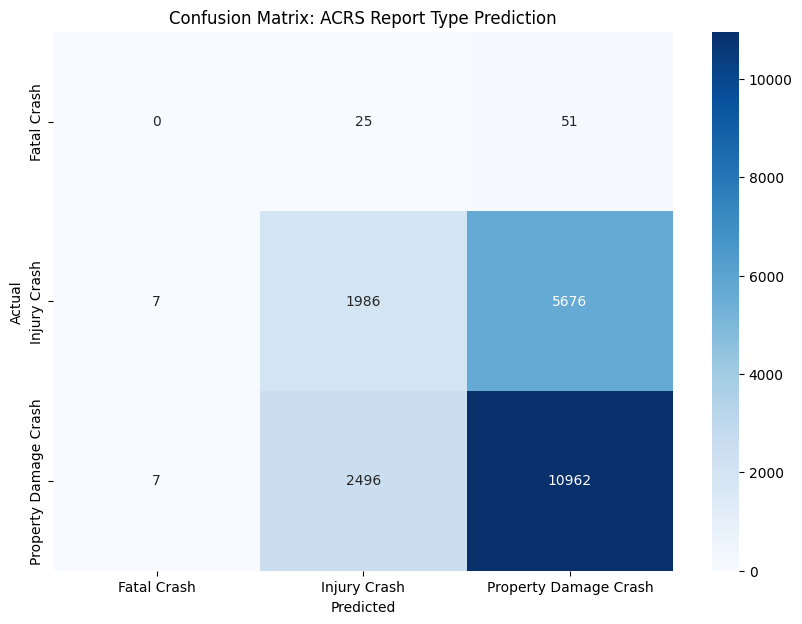

In [37]:
#training the random forrest classifier and fitting the model
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_model.fit(X_train_c, y_train_c)

#looking at the metric of the model
y_pred_c = clf_model.predict(X_test_c)

print("Accuracy Score:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

#confusion Matrix Visualization
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=clf_model.classes_,
           yticklabels=clf_model.classes_)
plt.title('Confusion Matrix: ACRS Report Type Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()